In [1]:
import ChessLens

from matplotlib import pyplot as plt
import numpy as np
import cv2

from Dataset.DataSetLoaders.ChessDataset import ChessDataset

/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [2]:
dataset = ChessDataset(
    config={
        "img_size": (640,640)
    }
)
dataloader = ChessDataset.getLoader(dataset, batch_size=4, num_worders=0)

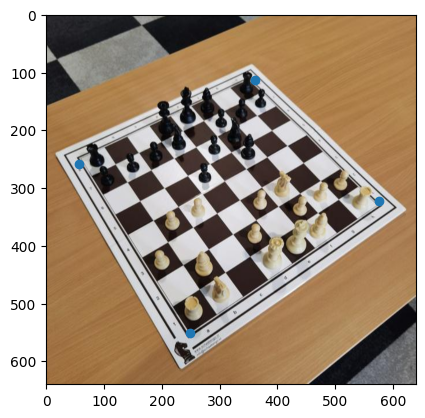

In [4]:
# for img, label in dataset:
    # _, H, W = img.shape
    # print(label)
    # plt.imshow(img.permute(1,2,0));
    # plt.scatter(label["corners"][:,0], label["corners"][:,1])

    # print(H, W)
    # break

img, _ = dataset[400]

# img = ChessLens.ChessLensImage("./Dataset/img_3.jpeg")
img = ChessLens.ChessLensImage(img)
img.detect_board()
_, H, W = img.img.shape
label = {
    "corners": img.board_detection
}

plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);

In [5]:
s = 0
cx = W/2
cy = H/2

In [6]:
# fx = 2739.79 * 640 / 2304
# fy = 2739.79 * 640/1728
fx = 2739.79 * W/4032
fy = 2739.79 * H/3024

K = np.array([
    [fx, s, cx],
    [0, fy, cy],
    [0,  0,  1]
]) # K: intrinsics of 3d -> 2d

In [7]:
cam_point = np.array([0,0,.5])
Z = cam_point[2]

def extrinsics_from_planar_points(image_pts, K, L=1.0):
    """
    image_pts: (4,2) image coordinates in pixels, in known order (clockwise or ccw)
    K: 3x3 camera intrinsics
    L: side length of the square in world coordinates (any unit)
    Returns:
        R: 3x3 rotation matrix (world→camera)
        t: 3x1 translation vector (world→camera)
        H: 3x3 homography (plane→image)
    """
    # Define square points on the world plane Z=0
    world_pts = np.array([
        [0, 0],
        [L, 0],
        [L, L],
        [0, L]
    ], dtype=np.float64)

    # Find homography (plane -> image)
    H, _ = cv2.findHomography(world_pts, image_pts)

    # Decompose using intrinsics
    K_inv = np.linalg.inv(K)
    h1, h2, h3 = H[:,0], H[:,1], H[:,2]

    # Normalize rotation columns
    lam = 1.0 / np.linalg.norm(K_inv @ h1)
    r1 = lam * (K_inv @ h1)
    r2 = lam * (K_inv @ h2)
    r3 = np.cross(r1, r2)

    R = np.column_stack((r1, r2, r3))
    # Enforce orthonormality via SVD
    U, _, Vt = np.linalg.svd(R)
    R = U @ Vt

    # Ensure a right-handed coordinate system
    if np.linalg.det(R) < 0:
        R[:, 2] *= -1

    t = lam * (K_inv @ h3)
    return R, t.reshape(3,1), H


# r_val = 1/np.sqrt(2)
# R_ = np.array([
#     [1, 0, 0],
#     [0, -r_val, -r_val],
#     [0, r_val, -r_val],
# ])

R_, t, H = extrinsics_from_planar_points(img.board_detection.numpy(), K, 1)
pitch = np.degrees(np.arctan2(R_[2,1], R_[1,1]))
print(pitch)

t = (-R_) @ cam_point.reshape((3,1))
# t = np.array([
#     [0],
#     [-Z * r_val],
#     [Z * r_val]
# ])

R = np.concat([R_, t], axis=1)
R = np.concat([R, np.array([[0,0,0,1]])], axis=0) # R: extrinsics of World -> Camera

-24.499668220842878


In [8]:
def from_3d_to_2d(points: np.ndarray, K: np.ndarray, R: np.ndarray):
    N = points.shape[0]
    points_ = np.concat([points, np.ones((N, 1))], axis=1)
    res_points = points_ @ R.T
    res_points = (res_points / res_points[:,[3]])[:, :3]
    res_points = res_points @ K.T
    res_points = (res_points/res_points[:, [2]])[:, :2]
    return res_points

def from_2d_to_3d(points: np.ndarray, K: np.ndarray, R: np.ndarray):
    N = points.shape[0]
    points_ = np.concat([points, np.ones((N, 1))], axis=1)
    res_points = points_ @ np.linalg.inv(K).T

    points_ = np.concat([res_points, np.ones((N, 1))], axis=1)
    res_points = points_ @ np.linalg.inv(R).T
    res_points = (res_points/res_points[:, [3]])[:, :3]

    return res_points

def trace_ray(directions: np.ndarray, cam_point: np.ndarray, Z_0: np.ndarray):
    N = directions.shape[0]
    if directions.shape[1] != 3 or len(directions.shape) != 2 \
        or cam_point.shape[0] != 3 or len(cam_point.shape) != 1 \
        or Z_0.shape[0] != N or len(Z_0.shape) != 1:
        raise Exception("Invalid input")
    
    t = ((Z_0-cam_point[2]) / (directions[:, 2] - cam_point[2]))
    p = cam_point + t.reshape(N, 1) * (directions - cam_point.reshape(1,3))
    return p

p = np.array([
    [1,2,3],
    [4,5,10]
])
print(p)
p1 = from_3d_to_2d(p, K, R)
print(p1)
p2 = from_2d_to_3d(p1, K, R)
print(p2)
p3 = trace_ray(p2, cam_point, np.array([3, 10]))
print(p3)

[[ 1  2  3]
 [ 4  5 10]]
[[     762.45      971.24]
 [     637.38      746.28]]
[[    0.54131      1.0826      1.8533]
 [    0.50271     0.62839      1.6939]]
[[          1           2           3]
 [          4           5          10]]


In [9]:
label["corners"]

tensor([[ 56., 258.],
        [361., 112.],
        [576., 323.],
        [248., 551.]])

In [10]:
corners_3d = trace_ray(from_2d_to_3d(label["corners"].numpy(), K, R), cam_point, np.zeros((4)))
corners_3d

array([[   0.093249,      0.4397,  5.5511e-17],
       [   -0.36365,     0.37334,           0],
       [   -0.43001,  -0.0023764,           0],
       [   0.026885,    0.063987,           0]])

In [11]:
corners_up_2d = from_3d_to_2d(corners_3d, K, R)
corners_up_2d

array([[         56,         258],
       [        361,         112],
       [        576,         323],
       [        248,         551]])

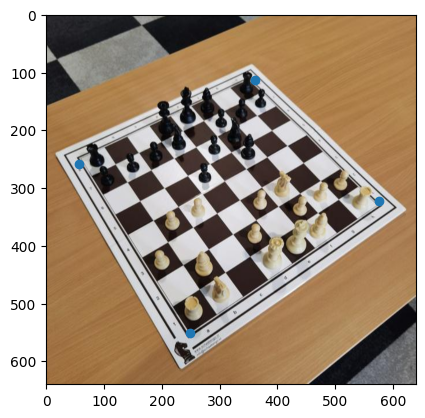

In [12]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(corners_up_2d[:,0], corners_up_2d[:,1]);

In [13]:
img.recognize_pieces()

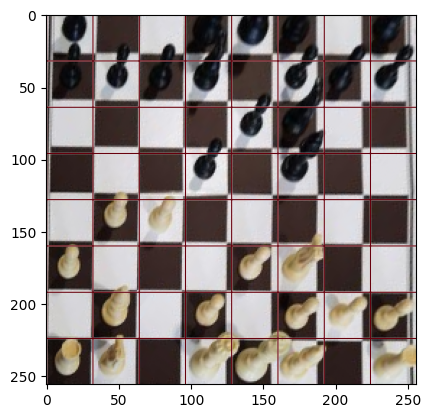

In [14]:
M = ChessLens.PieceDetection.piece_detector.piece_detector.M

warpped_img = cv2.warpPerspective(img.img.permute(1,2,0).numpy(), M.numpy(), (256,256))
plt.imshow(warpped_img);

grid = np.zeros((256,256))
grid[::32, :] = 1
grid[:, ::32] = 1
plt.imshow(grid, alpha = grid, cmap="Reds");

In [15]:
r = 2
c = 2

In [16]:
sq_box = np.array([
    [(c-1)*32, (r-1)*32],
    [(c)*32, (r-1)*32],
    [(c)*32, (r)*32],
    [(c-1)*32, (r)*32],
], dtype=np.float32)

In [17]:
M_inv = np.linalg.inv(M)

inverted_sq = []

for i in range(len(sq_box)):
    inverted_sq.append(M_inv @ np.concat([sq_box[i], np.ones(1)], axis=0))
    inverted_sq[-1] = (inverted_sq[-1] / inverted_sq[-1][2])[:2]

inverted_sq = np.stack(inverted_sq, axis=0)
inverted_sq

/tmp/ipykernel_43941/1142479384.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  inverted_sq.append(M_inv @ np.concat([sq_box[i], np.ones(1)], axis=0))


array([[      120.6,      266.07],
       [     163.29,      244.77],
       [     185.31,      274.16],
       [      142.1,      296.68]])

In [18]:
pts = trace_ray(from_2d_to_3d(inverted_sq, K, R), cam_point, np.zeros(4)) + np.concat([np.zeros((4,2)), .1*np.ones((4,1))], axis=1)
pts2 = from_3d_to_2d(pts, K, R)

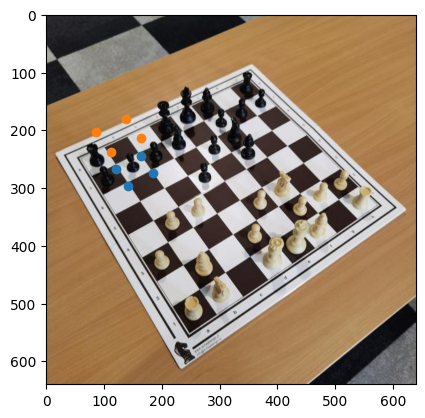

In [19]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(inverted_sq[:,0], inverted_sq[:,1]);
plt.scatter(pts2[:,0], pts2[:,1]);

In [20]:
xs = np.linspace(0,256, 9)
ys = np.linspace(0,256, 9)

X, Y = np.meshgrid(xs, ys)
points = np.stack([X,Y], axis=2)

points.shape, X.shape, Y.shape, points[3,6]

((9, 9, 2), (9, 9), (9, 9), array([        192,          96]))

In [21]:
tmp = np.concat([points, np.ones((9,9,1))], axis=2) @ M_inv.numpy().T

tmp = (tmp/tmp[:, :, [2]])[:, :, :2].reshape(-1, 2)
tmp

array([[         56,         258],
       [      100.1,      236.89],
       [     142.26,      216.71],
       [     182.63,      197.39],
       [     221.29,      178.88],
       [     258.37,      161.13],
       [     293.96,      144.09],
       [     328.14,      127.73],
       [        361,         112],
       [     75.909,      288.38],
       [      120.6,      266.07],
       [     163.29,      244.77],
       [     204.11,      224.39],
       [     243.17,      204.89],
       [      280.6,      186.21],
       [     316.49,       168.3],
       [     350.93,       151.1],
       [     384.02,      134.59],
       [     96.812,      320.28],
       [      142.1,      296.68],
       [     185.31,      274.16],
       [     226.59,      252.66],
       [     266.05,      232.09],
       [     303.82,      212.41],
       [     340.01,      193.55],
       [      374.7,      175.48],
       [        408,      158.12],
       [     118.79,      353.81],
       [     164.68,

In [22]:
elevated_tmp = trace_ray(from_2d_to_3d(tmp, K, R), cam_point, np.zeros((81)))
elevated_tmp += np.concat([np.zeros((81,2)), .1*np.ones((81, 1))], axis=1)
elevated_tmp = from_3d_to_2d(elevated_tmp, K, R)
elevated_tmp

array([[     10.059,       193.9],
       [     63.367,      170.66],
       [     113.93,      148.61],
       [     161.95,      127.68],
       [     207.62,      107.76],
       [     251.11,      88.804],
       [     292.56,       70.73],
       [     332.13,      53.481],
       [     369.93,      37.001],
       [     32.451,      228.25],
       [     86.655,      203.41],
       [     137.99,       179.9],
       [     186.68,      157.59],
       [     232.92,      136.41],
       [     276.89,      116.26],
       [     318.76,      97.083],
       [     358.67,      78.799],
       [     396.76,      61.351],
       [     56.181,      264.64],
       [      111.3,      238.07],
       [     163.41,      212.95],
       [     212.77,      189.15],
       [     259.57,      166.59],
       [     304.02,      145.16],
       [     346.29,      124.78],
       [     386.54,      105.38],
       [      424.9,      86.883],
       [     81.373,      303.28],
       [     137.41,

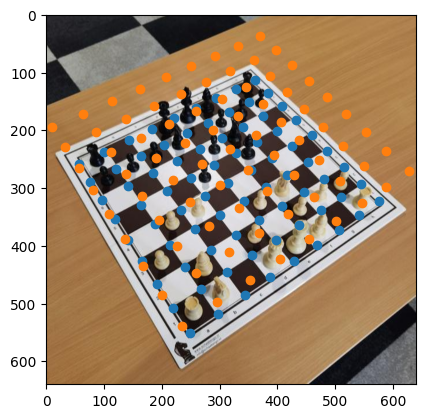

In [23]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(tmp[:,0], tmp[:,1]);
plt.scatter(elevated_tmp[:,0], elevated_tmp[:,1]);